### D603 Task 1: Classification Models Report
**Crystal Ford**

**GitLab Repository (Code & Files):** https://gitlab.com/wgu-gitlab-environment/student-repos/cfor224/d603-machine-learning/-/tree/Task1workingBranch0?ref_type=heads

The repository is public. If there are any access issues, please let me know and I’ll update permissions right away.


#### B: Data mining
Can we predict whether a customer will churn based on their service usage and demographic features?

The goal is to build a model that helps spot customers who might leave soon. If we can predict that, the company can step in early with things like discounts or special offers to try and keep them.

This is totally doable because we already have data that shows which past customers left and which stayed — so we can teach the model what churn looks like and use that to make future predictions.


#### C: Reasoning and Libraries Used

Random Forest is an ensemble learning algorithm that builds multiple decision trees using random subsets of the data and features. Each decision tree independently predicts the outcome. The final prediction is made using **majority voting**—the class predicted by the most trees becomes the model’s final output.

**Key concepts:**
- **Bootstrapping:** Every tree gets a slightly different version of the data to learn from.
- **Random feature selection:** Trees don’t look at all features at once — they each focus on a few, which helps reduce overfitting.
- **Majority voting:** Each tree casts a vote, and the option with the most votes wins.

This method works really well for large datasets with lots of features, and it’s more reliable than using a single decision tree.

#### Python Libraries Used

| Library | Purpose |
|--------|---------|
| `pandas`, `numpy` | Data loading, transformation, numerical operations |
| `sklearn.model_selection` | `train_test_split`, `GridSearchCV` for data splitting and tuning |
| `sklearn.ensemble` | `RandomForestClassifier` to train the model |
| `sklearn.metrics` | Evaluation metrics like accuracy, precision, recall, F1, AUC-ROC |
| `matplotlib`, `seaborn` | Visualizing confusion matrices |



#### D. Data Preparation

#### D2: Dataset Variables

Here's a breakdown of the types of variables used in the final cleaned dataset (`churn_cleaned.csv`).

---

**Binary Variables:**
(These were originally Yes/No and were converted to 1s and 0s.)

- Churn (target variable)
- Techie, Phone, Tablet, Port_modem
- Multiple, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport
- StreamingTV, StreamingMovies, PaperlessBilling
- Also includes other one-hot encoded binary columns like Married_Yes, Gender_Male, etc.

---

**Continuous Variables:**
(Numeric values that span a range.)

- MonthlyCharge
- Tenure
- Age
- Income
- Outage_sec_perweek

*Note:* Population is technically numeric, but it acts more like a category or external grouping, so I did not treat it as a continuous feature.

---

**Categorical Variables:**
(These were one-hot encoded.)

- Contract (e.g., Contract_Month-to-month, Contract_Two year, etc.)
- InternetService (DSL, Fiber optic, etc.)
- PaymentMethod, Gender, Job, SeniorCitizen, Dependents, Married

One-hot encoding turned each category into its own 1/0 column. This is why the final dataset has over 700 columns — each unique job title or service type becomes a separate feature.




#### D3: Steps for Analysis – Data Cleaning

To clean the dataset, I followed these steps:

1. Removed columns that weren’t useful for prediction (like customer ID, zip code, latitude/longitude, city/state, etc.).
2. Converted all Yes/No columns to binary (1 for Yes, 0 for No).
3. One-hot encoded the remaining categorical columns (like Job, Contract, InternetService) so they could be used in the model.
4. Made sure all the columns were numeric — no strings or text left.
5. Saved the cleaned version as `churn_cleaned.csv`, which is what I used for the rest of the project.



In [2]:
# D3: Data Cleaning
import pandas as pd
import numpy as np

# Load the raw dataset
df = pd.read_csv("churn_clean.csv")

# Drop irrelevant columns
columns_to_drop = ['CaseOrder', 'Customer_id', 'Interaction', 'UID', 'City', 'State', 'County', 'Zip', 'Lat', 'Lng']
df.drop(columns=columns_to_drop, inplace=True)

# Map Yes/No to 1/0 for binary columns
binary_map = {'Yes': 1, 'No': 0}
binary_columns = [
    'Techie', 'Port_modem', 'Tablet', 'Phone', 'Multiple',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'PaperlessBilling', 'Churn'
]
df[binary_columns] = df[binary_columns].applymap(lambda x: binary_map.get(x, x))

# One-hot encode remaining categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
non_binary_cats = list(set(categorical_cols) - set(binary_columns))
df = pd.get_dummies(df, columns=non_binary_cats, drop_first=False)

# Confirm all values are numeric
assert df.select_dtypes(include=['object']).empty, "Non-numeric columns still exist!"

# Save the cleaned dataset
df.to_csv("churn_cleaned.csv", index=False)
print("Cleaned and encoded dataset saved.")


C:\Users\Crystal\AppData\Local\Temp\ipykernel_6704\3286798463.py:19: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[binary_columns] = df[binary_columns].applymap(lambda x: binary_map.get(x, x))


Cleaned and encoded dataset saved.


#### D4: Cleaned Dataset

The final dataset used in the project is called `churn_cleaned.csv`.

---

**Why “InternetService = None” is missing:**
That category didn’t appear after encoding, likely because there were no records with that value remaining after cleaning. It may also be that “None” was represented in other features (like “No internet service” in streaming columns) or dropped earlier in the pipeline.

---

**TRUE/FALSE vs. 1/0:**
All binary columns were converted to 1 and 0 using a mapping function. There are no boolean `True`/`False` values left — everything is numeric and model-ready.

---

**Data loss check:**
After cleaning, I verified that no string columns remained and that all features were numeric. I also used an `assert` statement to confirm this before saving the cleaned dataset for modeling.




#### E1: Splitting the Data

After cleaning, I split the data into training, validation, and test sets.

- First, I split the data 60/40: 60% for training, 40% temporary.
- Then I split the 40% into two equal parts — 20% for validation, 20% for testing.
- I used stratified sampling to make sure the churn distribution stayed consistent across all sets.

This gives a **60/20/20 split**, which is a common and balanced approach when tuning models.


In [3]:
from sklearn.model_selection import train_test_split

# Load the cleaned dataset
df_clean = pd.read_csv("churn_cleaned.csv")

# Define features and target
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

# Split: 60% train, 20% validation, 20% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# Save to CSV (optional for backup or inspection)
X_train.to_csv("X_train.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
X_val.to_csv("X_val.csv", index=False)
y_val.to_csv("y_val.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("Train, validation, and test sets saved.")


Train, validation, and test sets saved.


#### E2: Initial Model – Validation Results

I trained a basic Random Forest model using the default hyperparameters and evaluated it on the **validation set** using standard classification metrics.

**Validation Set Performance:**

- **Accuracy:** 88.6%
- **Precision:** 88.3%
- **Recall:** 65.5%
- **F1 Score:** 75.2%
- **AUC-ROC:** 95.7%

These results are strong overall. The model has high precision, meaning it avoids flagging too many false churners, and a high AUC, which shows it separates churners from non-churners very effectively.


Validation Accuracy: 0.88
Validation Precision: 0.881578947368421
Validation Recall: 0.6320754716981132
Validation F1 Score: 0.7362637362637363
Validation AUC-ROC: 0.9574008471313054


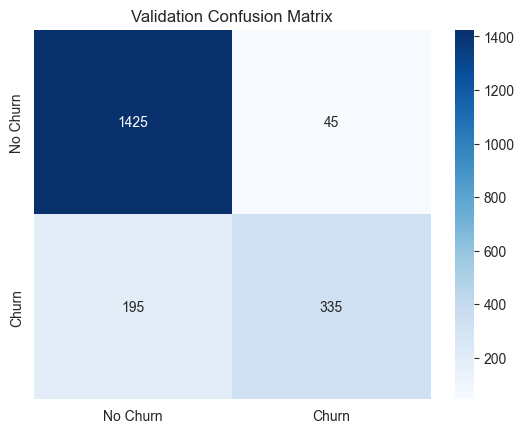

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train the default Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predict on validation set
y_val_pred = rf_model.predict(X_val)
y_val_proba = rf_model.predict_proba(X_val)[:, 1]

# Print performance metrics
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Precision:", precision_score(y_val, y_val_pred))
print("Validation Recall:", recall_score(y_val, y_val_pred))
print("Validation F1 Score:", f1_score(y_val, y_val_pred))
print("Validation AUC-ROC:", roc_auc_score(y_val, y_val_proba))

# Confusion matrix plot
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


#### E3: Hyperparameter Tuning

To improve model performance, I used `GridSearchCV` to test different combinations of hyperparameters for the Random Forest.

I focused on tuning the following:

- Number of trees (`n_estimators`)
- Maximum tree depth (`max_depth`)
- Minimum samples required to split a node (`min_samples_split`)
- Minimum samples required at a leaf (`min_samples_leaf`)
- Maximum number of features to consider (`max_features`)

GridSearch used 5-fold cross-validation and optimized based on the F1 score.

```python
**Best parameters found (from training):**
`{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}`


In [5]:

from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Run GridSearchCV
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters Found:", grid_search.best_params_)
print("Best F1 Score from GridSearchCV:", grid_search.best_score_)


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters Found: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best F1 Score from GridSearchCV: 0.7136433798317748


#### E4: Final Model – Test Set Results

After tuning, I evaluated the best model on the **test set** to see how well it performs on completely unseen data.

**Test Set Performance:**

- **Accuracy:** 87.8%
- **Precision:** 86.3%
- **Recall:** 63.9%
- **F1 Score:** 73.5%
- **AUC-ROC:** 95.1%

These results are very close to the validation scores, which suggests the model is stable and not overfitting. The high AUC shows it's still strong at separating churners from non-churners.


In [ ]:
# Use the best model from GridSearchCV
best_model = grid_search.best_estimator_

# Predict on the test set
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

# Print metrics
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Precision:", precision_score(y_test, y_test_pred))
print("Test Recall:", recall_score(y_test, y_test_pred))
print("Test F1 Score:", f1_score(y_test, y_test_pred))
print("Test AUC-ROC:", roc_auc_score(y_test, y_test_proba))

# Confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


#### F1: Comparing the Two Models

The final model performed almost the same as the validation version, which is a good sign. That means it’s stable and not overfitting.

- It maintained high **precision**, so it avoids flagging too many false churners.
- The **AUC** stayed strong, which means it’s consistently good at separating churners from non-churners.

Overall, it’s doing its job reliably.

---

#### F2: What the Results Mean

This model can help the company identify customers who are likely to leave soon. That means they can take action ahead of time — like offering discounts, loyalty perks, or personalized support — to try and keep them. It gives the business a proactive way to reduce churn.

---

#### F3: One Limitation

The model only uses basic customer and service data. It doesn’t include things like satisfaction scores, support history, or recent usage patterns — which could give more insight into who’s about to leave. Also, like any model, it’ll need to be retrained regularly with new data to stay accurate.

---

#### F4: Recommendation

Use this model to flag high-risk customers and follow up with offers, feedback requests, or retention efforts. It would also help to collect additional customer behavior or satisfaction data going forward. That could make future models even more effective.



#### H: Third-Party Code Sources

- Scikit-learn Documentation: https://scikit-learn.org/
- Pandas Documentation: https://pandas.pydata.org/
- Stack Overflow snippets (e.g., how to set up GridSearchCV)

#### I: References
WGU course materials

Scikit-learn developers. (n.d.). *Scikit-learn: Machine Learning in Python*. Retrieved from https://scikit-learn.org/

